Entrenando Random Forest... (esto puede tardar)

--- RESULTADOS RANDOM FOREST ---
Número de parámetros (nodos totales): 49594
Accuracy Train: 1.0000
Accuracy Val:   0.6719
Accuracy Test:  0.6897


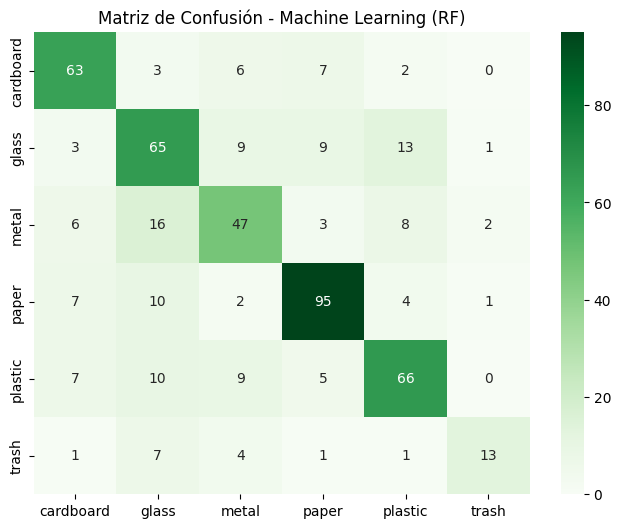

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import glob
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================================
# 1. CARGA Y PREPROCESAMIENTO
# =========================================================
PATH_DATOS = 'data/' 
IMG_SIZE = (64, 64) 

def cargar_datos(path):
    X_list, y_list = [], []
    categorias = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    for idx, cat in enumerate(categorias):
        files = glob.glob(os.path.join(path, cat, '*'))
        for f in files:
            try:
                img = Image.open(f).convert('RGB').resize(IMG_SIZE)
                X_list.append(np.array(img))
                y_list.append(idx)
            except: continue
    return np.array(X_list), np.array(y_list), categorias

X_img, y, nombres_clases = cargar_datos(PATH_DATOS)
X_flat = X_img.reshape(X_img.shape[0], -1) / 255.0

# DIVISIÓN (60% Train, 20% Val, 20% Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

# =========================================================
# 2. ENTRENAMIENTO RANDOM FOREST
# =========================================================
print("Entrenando Random Forest... (esto puede tardar)")
# Usamos 100 árboles y limitamos profundidad para evitar que el archivo pese gigas
model_ml = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
model_ml.fit(X_train, y_train)

# =========================================================
# 3. CÁLCULO DE PARÁMETROS (Requisito del profesor)
# =========================================================
# En Random Forest, los "parámetros" son el número total de nodos en todos los árboles
total_nodos = sum([tree.tree_.node_count for tree in model_ml.estimators_])

# =========================================================
# 4. EVALUACIÓN
# =========================================================
acc_train = accuracy_score(y_train, model_ml.predict(X_train))
acc_val = accuracy_score(y_val, model_ml.predict(X_val))
acc_test = accuracy_score(y_test, model_ml.predict(X_test))

print(f"\n--- RESULTADOS RANDOM FOREST ---")
print(f"Número de parámetros (nodos totales): {total_nodos}")
print(f"Accuracy Train: {acc_train:.4f}")
print(f"Accuracy Val:   {acc_val:.4f}")
print(f"Accuracy Test:  {acc_test:.4f}")

# Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, model_ml.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nombres_clases, yticklabels=nombres_clases, cmap='Greens')
plt.title("Matriz de Confusión - Machine Learning (RF)")
plt.show()